#  **Bagging Ensemble – End-to-End Implementation**

### **Import Libraries**

In [2]:


import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import accuracy_score, classification_report

### **Load Dataset**

In [3]:
df = pd.read_csv('C:/Users/Awais/Desktop/100_days_of_ML/Day68_Bagging/iris.csv')

In [4]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [5]:
df = df.iloc[:,1:]

In [13]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [24]:
# Convert species to numeric
df['species'] = df['species'].astype('category').cat.codes

In [18]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [19]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


## **Train-Test Split**

In [25]:
X = df.drop(columns=['species'])
y = df['species']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

## Base Model (Decision Tree)

In [28]:
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)

y_pred_base = base_model.predict(X_test)

print("Base Model Accuracy:", accuracy_score(y_test, y_pred_base))

Base Model Accuracy: 0.76


# Apply Bagging

In [29]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,        # number of trees
    max_samples=0.8,        # 80% data per model
    bootstrap=True,
    random_state=42
)

bagging_model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


## Predictions

In [30]:
y_pred_bag = bagging_model.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.8


In [31]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bag))


Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.86      0.83        14
           1       0.80      0.73      0.76        11

    accuracy                           0.80        25
   macro avg       0.80      0.79      0.79        25
weighted avg       0.80      0.80      0.80        25



In [32]:
print("Base Model Accuracy:", accuracy_score(y_test, y_pred_base))
print("Bagging Model Accuracy:", accuracy_score(y_test, y_pred_bag))

Base Model Accuracy: 0.76
Bagging Model Accuracy: 0.8


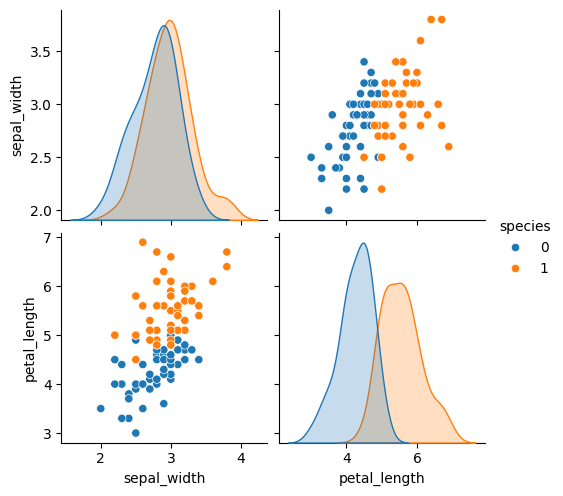

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='species')
plt.show()

## 2nd way

In [34]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [35]:
df_train

,sepal_width,petal_length,species
88,3.0,4.1,0
136,3.4,5.6,1
96,2.9,4.2,0
137,3.1,5.5,1
89,2.5,4.0,0
63,2.9,4.7,0
134,2.6,5.6,1
119,2.2,5.0,1
79,2.6,3.5,0
120,3.2,5.7,1


In [36]:
df_val

,sepal_width,petal_length,species
74,2.9,4.3,0
117,3.8,6.7,1
86,3.1,4.7,0
57,2.4,3.3,0
51,3.2,4.5,0


In [37]:
df_test

,sepal_width,petal_length,species
68,2.2,4.5,0
69,2.5,3.9,0
83,2.7,5.1,0
78,2.9,4.5,0
106,2.5,4.5,1


In [38]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [39]:
y_test

array([0, 1, 0, 0, 0], dtype=int8)

# Case 1 - Bagging

In [40]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
136,3.4,5.6,1
137,3.1,5.5,1
119,2.2,5.0,1
96,2.9,4.2,0
134,2.6,5.6,1
137,3.1,5.5,1
79,2.6,3.5,0
63,2.9,4.7,0


In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [68]:
# 1. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 2. Create model
dt_bag1 = DecisionTreeClassifier()

# 3. TRAIN (Most important step)
dt_bag1.fit(X_train, y_train)

# 4. Evaluate
evaluate(dt_bag1, X_test, y_test)

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [ ]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
120,3.2,5.7,1
120,3.2,5.7,1
120,3.2,5.7,1
136,3.4,5.6,1
119,2.2,5.0,1
136,3.4,5.6,1
136,3.4,5.6,1
134,2.6,5.6,1


In [71]:
dt_bag2 = DecisionTreeClassifier()
dt_bag2.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [72]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
136,3.4,5.6,1
88,3.0,4.1,0
63,2.9,4.7,0
63,2.9,4.7,0
79,2.6,3.5,0
119,2.2,5.0,1
120,3.2,5.7,1
96,2.9,4.2,0


In [73]:
dt_bag3 = DecisionTreeClassifier()
dt_bag3.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [74]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [75]:
df_test

,sepal_width,petal_length,species
68,2.2,4.5,0
69,2.5,3.9,0
83,2.7,5.1,0
78,2.9,4.5,0
106,2.5,4.5,1


In [78]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,4.5]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,4.5]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,4.5]).reshape(1,2)))

Predictor 1 [0]
Predictor 2 [0]
Predictor 3 [0]


c:\Users\Awais\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Awais\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Awais\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [79]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
88,3.0,4.1,0
136,3.4,5.6,1
96,2.9,4.2,0
137,3.1,5.5,1
89,2.5,4.0,0
63,2.9,4.7,0
134,2.6,5.6,1
119,2.2,5.0,1
79,2.6,3.5,0
120,3.2,5.7,1


In [80]:
df_train.sample(8)

,sepal_width,petal_length,species
136,3.4,5.6,1
88,3.0,4.1,0
63,2.9,4.7,0
120,3.2,5.7,1
79,2.6,3.5,0
134,2.6,5.6,1
96,2.9,4.2,0
89,2.5,4.0,0


# Random Subspaces

In [81]:
df1=pd.read_csv('C:/Users/Awais/Desktop/100_days_of_ML/Day68_Bagging/iris.csv')
df1 = df1.sample(10)

In [82]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
66,5.6,3.0,4.5,1.5,versicolor
91,6.1,3.0,4.6,1.4,versicolor
72,6.3,2.5,4.9,1.5,versicolor
116,6.5,3.0,5.5,1.8,virginica
36,5.5,3.5,1.3,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa
73,6.1,2.8,4.7,1.2,versicolor
131,7.9,3.8,6.4,2.0,virginica
47,4.6,3.2,1.4,0.2,setosa
39,5.1,3.4,1.5,0.2,setosa


In [55]:
df1.sample(2,replace=True,axis=1)

,sepal_width,sepal_width
91,3.0,3.0
63,2.9,2.9
20,3.4,3.4
116,3.0,3.0
16,3.9,3.9
94,2.7,2.7
131,3.8,3.8
32,4.1,4.1
119,2.2,2.2
87,2.3,2.3


# Random Patches

In [56]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
91,6.1,3.0,4.6,1.4,versicolor
63,6.1,2.9,4.7,1.4,versicolor
20,5.4,3.4,1.7,0.2,setosa
116,6.5,3.0,5.5,1.8,virginica
16,5.4,3.9,1.3,0.4,setosa
94,5.6,2.7,4.2,1.3,versicolor
131,7.9,3.8,6.4,2.0,virginica
32,5.2,4.1,1.5,0.1,setosa
119,6.0,2.2,5.0,1.5,virginica
87,6.3,2.3,4.4,1.3,versicolor


In [57]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,species,petal_length
94,versicolor,4.2
116,virginica,5.5
119,virginica,5.0
87,versicolor,4.4
119,virginica,5.0
94,versicolor,4.2
32,setosa,1.5
131,virginica,6.4
